In [1]:
print("Hello, World!")

Hello, World!


In [3]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


import torchvision
import torchvision.transforms as transforms

### Part 1

In [4]:
#initialize random values
images = torch.rand(16,3, 32, 32)   
print(images.shape)

torch.Size([16, 3, 32, 32])


In [5]:
#reshape the images to (16, 3072)
x=images.view(16, -1)
print(x.shape)

torch.Size([16, 3072])


In [6]:
#initialize random weights and bias
W=torch.rand(10,3072)*0.01
B=torch.zeros(10)

In [7]:
#forward pass
Y=torch.matmul(x,W.t())+B
print(Y.shape)

torch.Size([16, 10])


In [8]:
#enbling autograd for weights and bias
W.requires_grad=True
B.requires_grad=True

targets=torch.randint(0,10,(16,))

In [9]:
#use cross entropy loss
loss_fn=nn.CrossEntropyLoss()

In [10]:
#training loop
learning_rate=0.01

for epoch in range(100):
    Y=torch.matmul(x,W.t())+B
    loss=loss_fn(Y,targets)
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    
    loss.backward()
    
    with torch.no_grad():
        W-=learning_rate*W.grad
        B-=learning_rate*B.grad
        
        W.grad.zero_()
        B.grad.zero_()

Epoch 1, Loss: 2.3012
Epoch 2, Loss: 1.9909
Epoch 3, Loss: 1.8449
Epoch 4, Loss: 1.7139
Epoch 5, Loss: 1.5925
Epoch 6, Loss: 1.4791
Epoch 7, Loss: 1.3732
Epoch 8, Loss: 1.2746
Epoch 9, Loss: 1.1829
Epoch 10, Loss: 1.0980
Epoch 11, Loss: 1.0196
Epoch 12, Loss: 0.9475
Epoch 13, Loss: 0.8812
Epoch 14, Loss: 0.8205
Epoch 15, Loss: 0.7649
Epoch 16, Loss: 0.7142
Epoch 17, Loss: 0.6678
Epoch 18, Loss: 0.6255
Epoch 19, Loss: 0.5869
Epoch 20, Loss: 0.5516
Epoch 21, Loss: 0.5194
Epoch 22, Loss: 0.4900
Epoch 23, Loss: 0.4630
Epoch 24, Loss: 0.4383
Epoch 25, Loss: 0.4156
Epoch 26, Loss: 0.3948
Epoch 27, Loss: 0.3756
Epoch 28, Loss: 0.3578
Epoch 29, Loss: 0.3415
Epoch 30, Loss: 0.3263
Epoch 31, Loss: 0.3123
Epoch 32, Loss: 0.2992
Epoch 33, Loss: 0.2871
Epoch 34, Loss: 0.2758
Epoch 35, Loss: 0.2652
Epoch 36, Loss: 0.2553
Epoch 37, Loss: 0.2461
Epoch 38, Loss: 0.2374
Epoch 39, Loss: 0.2293
Epoch 40, Loss: 0.2216
Epoch 41, Loss: 0.2144
Epoch 42, Loss: 0.2076
Epoch 43, Loss: 0.2012
Epoch 44, Loss: 0.19

## Observations

- Each pixel acts as an input feature for out nn hence why we have to flatten the images.

- Tensors create a computational graph to track the opterations which build that graph while numpy arrays just hold values.

### Part 2

In [11]:
#Ann class
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1=nn.Linear(3072,512)
        self.fc2=nn.Linear(512,256)
        self.fc3=nn.Linear(256,10)
        
    def forward(self,x):
        x=x.view(x.size(0),-1)
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x

In [12]:
#Data normalization for training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [13]:
#Load CIFAR-10 dataset
train_data=torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data=torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
#Data loaders
train_loader=torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader=torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

In [14]:
image,lable=train_data[0]
print(image.shape)
print(len(train_data))
print(len(test_data))

torch.Size([3, 32, 32])
50000
10000


In [15]:
#creating and model and using the cross entropy loss
model =ANN()
criterion=nn.CrossEntropyLoss()
learning_rate=0.01

In [16]:
#Training loop
for epoch in range(5):
    total_loss=0.0
    for images, labels in train_loader:
        outputs=model(images)
        loss=criterion(outputs, labels)

        loss.backward()
        
        with torch.no_grad():
            for param in model.parameters():
                param-=learning_rate*param.grad
        model.zero_grad()
        total_loss+=loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 2.0339
Epoch 2, Loss: 1.7488
Epoch 3, Loss: 1.6316
Epoch 4, Loss: 1.5570
Epoch 5, Loss: 1.4954


In [17]:
#Evaluation on test set
correct =0
total=0

with torch.no_grad():
    for images, labels in test_loader:
        outputs=model(images)
        _, predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
accuracy=100*correct/total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 47.65%


## Observations

- yes, the loss value did decrease in the 5 epochs we optimized the model for.

- While decreasing the learning rate slowed down the optimization of the model , increasing the learning rate lead to over shooting the the eastimated values leading to decreased accuracy.

### Part 3

In [18]:
from torch.utils.data import Subset
train_subset=Subset(train_data, list(range(100)))


In [19]:
sub_train_loader=torch.utils.data.DataLoader(train_subset, batch_size=10, shuffle=True)    
print("Batches:", len(sub_train_loader))
print("Samples:", len(train_subset))

Batches: 10
Samples: 100


In [20]:
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001,momentum=0.9)

std_train_acc =[]
std_train_loss =[]
std_val_acc =[]

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in sub_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_acc = compute_accuracy(model, sub_train_loader)
    val_acc = compute_accuracy(model, test_loader)

    std_train_acc.append(train_acc)
    std_train_loss.append(running_loss / len(sub_train_loader))
    std_val_acc.append(val_acc)

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch 01 | Train Acc: 0.1500 | Val Acc: 0.0960
Epoch 02 | Train Acc: 0.2000 | Val Acc: 0.1066
Epoch 03 | Train Acc: 0.3000 | Val Acc: 0.1190
Epoch 04 | Train Acc: 0.3400 | Val Acc: 0.1306
Epoch 05 | Train Acc: 0.3400 | Val Acc: 0.1292
Epoch 06 | Train Acc: 0.3300 | Val Acc: 0.1296
Epoch 07 | Train Acc: 0.3800 | Val Acc: 0.1323
Epoch 08 | Train Acc: 0.3700 | Val Acc: 0.1297
Epoch 09 | Train Acc: 0.3700 | Val Acc: 0.1296
Epoch 10 | Train Acc: 0.3900 | Val Acc: 0.1321
Epoch 11 | Train Acc: 0.3800 | Val Acc: 0.1334
Epoch 12 | Train Acc: 0.3800 | Val Acc: 0.1333
Epoch 13 | Train Acc: 0.3900 | Val Acc: 0.1368
Epoch 14 | Train Acc: 0.4000 | Val Acc: 0.1397
Epoch 15 | Train Acc: 0.3900 | Val Acc: 0.1404
Epoch 16 | Train Acc: 0.4000 | Val Acc: 0.1428
Epoch 17 | Train Acc: 0.4100 | Val Acc: 0.1456
Epoch 18 | Train Acc: 0.4700 | Val Acc: 0.1529
Epoch 19 | Train Acc: 0.5000 | Val Acc: 0.1551
Epoch 20 | Train Acc: 0.5300 | Val Acc: 0.1603
Epoch 21 | Train Acc: 0.5800 | Val Acc: 0.1665
Epoch 22 | Tr

In [22]:
class DropoutANN(nn.Module):
    def __init__(self):
        super(DropoutANN, self).__init__()
        self.fc1=nn.Linear(3072,512)
        self.dropout1=nn.Dropout(0.5)
        self.fc2=nn.Linear(512,256)
        self.dropout2=nn.Dropout(0.5)
        self.fc3=nn.Linear(256,10)
        
    def forward(self,x):
        x=x.view(x.size(0),-1)
        x=F.relu(self.fc1(x))
        x=self.dropout1(x)
        x=F.relu(self.fc2(x))
        x=self.dropout2(x)
        x=self.fc3(x)
        return x

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

drop_model = DropoutANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(drop_model.parameters(), lr=0.001,momentum=0.9)
drop_train_acc =[]
drop_train_loss =[]
drop_val_acc =[]
EPOCHS = 100
for epoch in range(EPOCHS):
    drop_model.train()
    running_loss = 0.0

    for images, labels in sub_train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = drop_model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_acc = compute_accuracy(drop_model, sub_train_loader)
    val_acc = compute_accuracy(drop_model, test_loader)

    drop_train_acc.append(train_acc)
    drop_train_loss.append(running_loss / len(sub_train_loader))
    drop_val_acc.append(val_acc)

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01 | Train Acc: 0.1900 | Val Acc: 0.0946
Epoch 02 | Train Acc: 0.2200 | Val Acc: 0.1005
Epoch 03 | Train Acc: 0.2500 | Val Acc: 0.1047
Epoch 04 | Train Acc: 0.2600 | Val Acc: 0.1066
Epoch 05 | Train Acc: 0.3100 | Val Acc: 0.1120
Epoch 06 | Train Acc: 0.3900 | Val Acc: 0.1234
Epoch 07 | Train Acc: 0.3500 | Val Acc: 0.1276
Epoch 08 | Train Acc: 0.3600 | Val Acc: 0.1308
Epoch 09 | Train Acc: 0.4000 | Val Acc: 0.1338
Epoch 10 | Train Acc: 0.3900 | Val Acc: 0.1401
Epoch 11 | Train Acc: 0.4000 | Val Acc: 0.1431
Epoch 12 | Train Acc: 0.3900 | Val Acc: 0.1430
Epoch 13 | Train Acc: 0.3700 | Val Acc: 0.1480
Epoch 14 | Train Acc: 0.3800 | Val Acc: 0.1512
Epoch 15 | Train Acc: 0.3900 | Val Acc: 0.1545
Epoch 16 | Train Acc: 0.3900 | Val Acc: 0.1568
Epoch 17 | Train Acc: 0.4300 | Val Acc: 0.1590
Epoch 18 | Train Acc: 0.4500 | Val Acc: 0.1631
Epoch 19 | Train Acc: 0.4700 | Val Acc: 0.1673
Epoch 20 | Train Acc: 0.5200 | Val Acc: 0.1736
Epoch 21 | Train Acc: 0.5200 | Val Acc: 0.1740
Epoch 22 | Tr

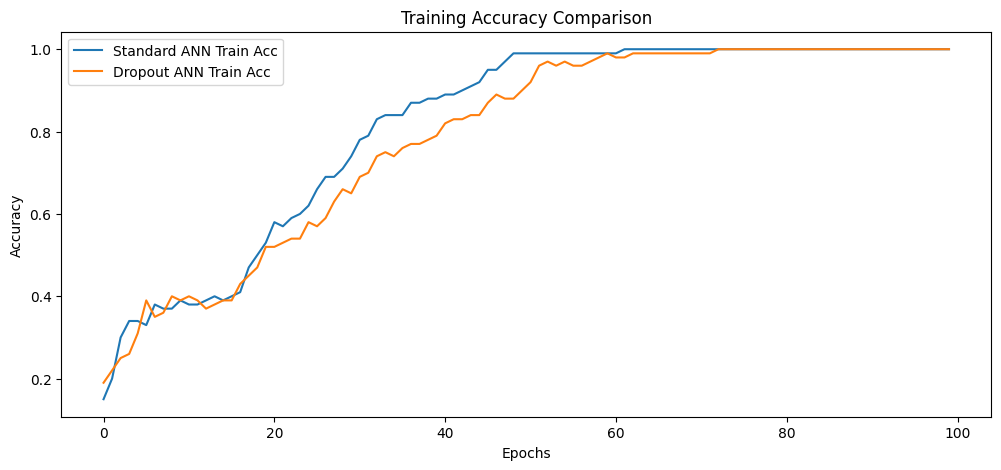

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(std_train_acc, label='Standard ANN Train Acc')
plt.plot(drop_train_acc, label='Dropout ANN Train Acc')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

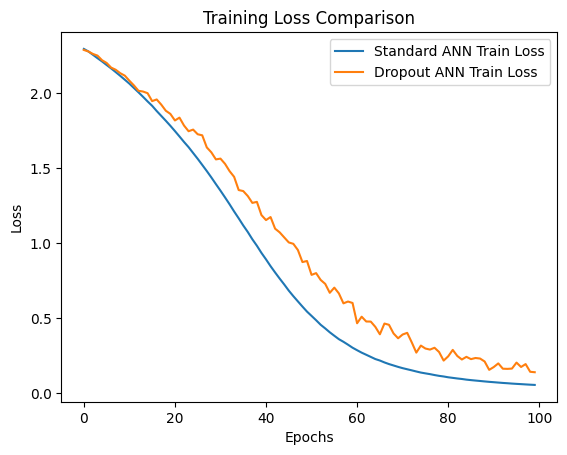

In [25]:
plt.plot(std_train_loss, label='Standard ANN Train Loss')
plt.plot(drop_train_loss, label='Dropout ANN Train Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

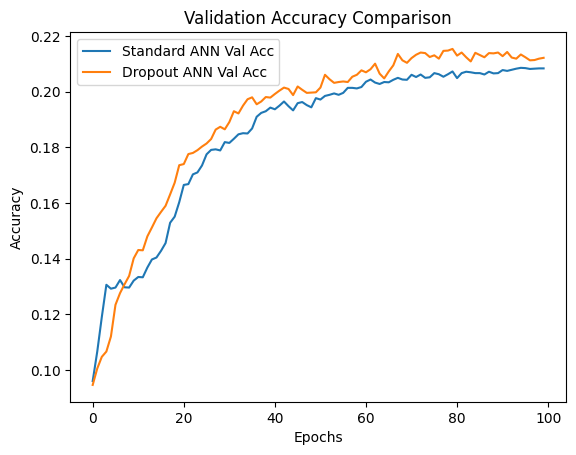

In [26]:
plt.plot(std_val_acc, label='Standard ANN Val Acc')
plt.plot(drop_val_acc, label='Dropout ANN Val Acc')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Observations

- Yes dropout did slow down the training accuracy.

- Yes it did increase the validation accuracy but only marginally.

### Part 4

In [ ]:
class_name=['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
class Neuralnet(nn.Module):
    def __init__(self):
        super(Neuralnet, self).__init__()
        self.conv1=nn.Conv2d(3,12,5)#12,28,28
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(12,24,5)#24,10,10
        self.fc1=nn.Linear(24*5*5,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)
        
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=torch.flatten(x,1)
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_net=Neuralnet().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model_net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(30):
    running_loss=0.0
    for images, labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)
        
        optimizer.zero_grad()
        outputs=model_net(images)
        loss=criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()
    print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(train_loader):.4f}")

Epoch 01 | Loss: 2.2919
Epoch 02 | Loss: 2.0568
Epoch 03 | Loss: 1.8080
Epoch 04 | Loss: 1.6458
Epoch 05 | Loss: 1.5334
Epoch 06 | Loss: 1.4524
Epoch 07 | Loss: 1.3888
Epoch 08 | Loss: 1.3351
Epoch 09 | Loss: 1.2815
Epoch 10 | Loss: 1.2320
Epoch 11 | Loss: 1.1878
Epoch 12 | Loss: 1.1458
Epoch 13 | Loss: 1.1043
Epoch 14 | Loss: 1.0740
Epoch 15 | Loss: 1.0343
Epoch 16 | Loss: 1.0065
Epoch 17 | Loss: 0.9757
Epoch 18 | Loss: 0.9549
Epoch 19 | Loss: 0.9285
Epoch 20 | Loss: 0.9054
Epoch 21 | Loss: 0.8848
Epoch 22 | Loss: 0.8635
Epoch 23 | Loss: 0.8462
Epoch 24 | Loss: 0.8232
Epoch 25 | Loss: 0.8083
Epoch 26 | Loss: 0.7863
Epoch 27 | Loss: 0.7684
Epoch 28 | Loss: 0.7503
Epoch 29 | Loss: 0.7329
Epoch 30 | Loss: 0.7179


In [ ]:
correct=0
total=0

model_net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)

        outputs=model_net(images)
        _, predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
accuracy=100*correct/total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 67.48%


In [ ]:
new_transform=transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [ ]:
import os
from pathlib import Path

# Get the directory where the notebook is located
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()

def load_image(image_path):
    image=Image.open(image_path)
    image=new_transform(image)
    return image.unsqueeze(0)

In [ ]:
import os
from pathlib import Path


image_paths=[
     'Golden-Retriever.jpg', 
   'pngtree-a-plane-is-flying-over-runway-isolated-png-image_19769615.jpg', 
     '20018955.jpg'
]
images=[load_image(str(path)) for path in image_paths]

model_net.eval()
with torch.no_grad():
    for i, image in enumerate(images):
        image=image.to(device)
        output=model_net(image)
        _, predicted=torch.max(output.data,1)
        print(f"Image {i+1} predicted class: {class_name[predicted.item()]}")

Image 1 predicted class: dog
Image 2 predicted class: plane
Image 3 predicted class: bird


## Observations

- CNNs can take into account the context around the a single pixel rather than just looking at that one input, the parametrs decrease due to filering and pooling but the context is preserved which leads to higher accuracy.

- The filter to detect an edge might highlight the sections represented by endge allowing us to create a feature map which take the edge into account.